# Residuals, Intervals And Risk

Tests whether forecast errors are centered, stable across scale and adequately covered by empirical prediction intervals.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = Path("Ai miroservices/modeling/project_operational_baseline").resolve()
OUT = ROOT / "outputs"
EVAL = OUT / "evaluator"
sns.set_theme(style="whitegrid")

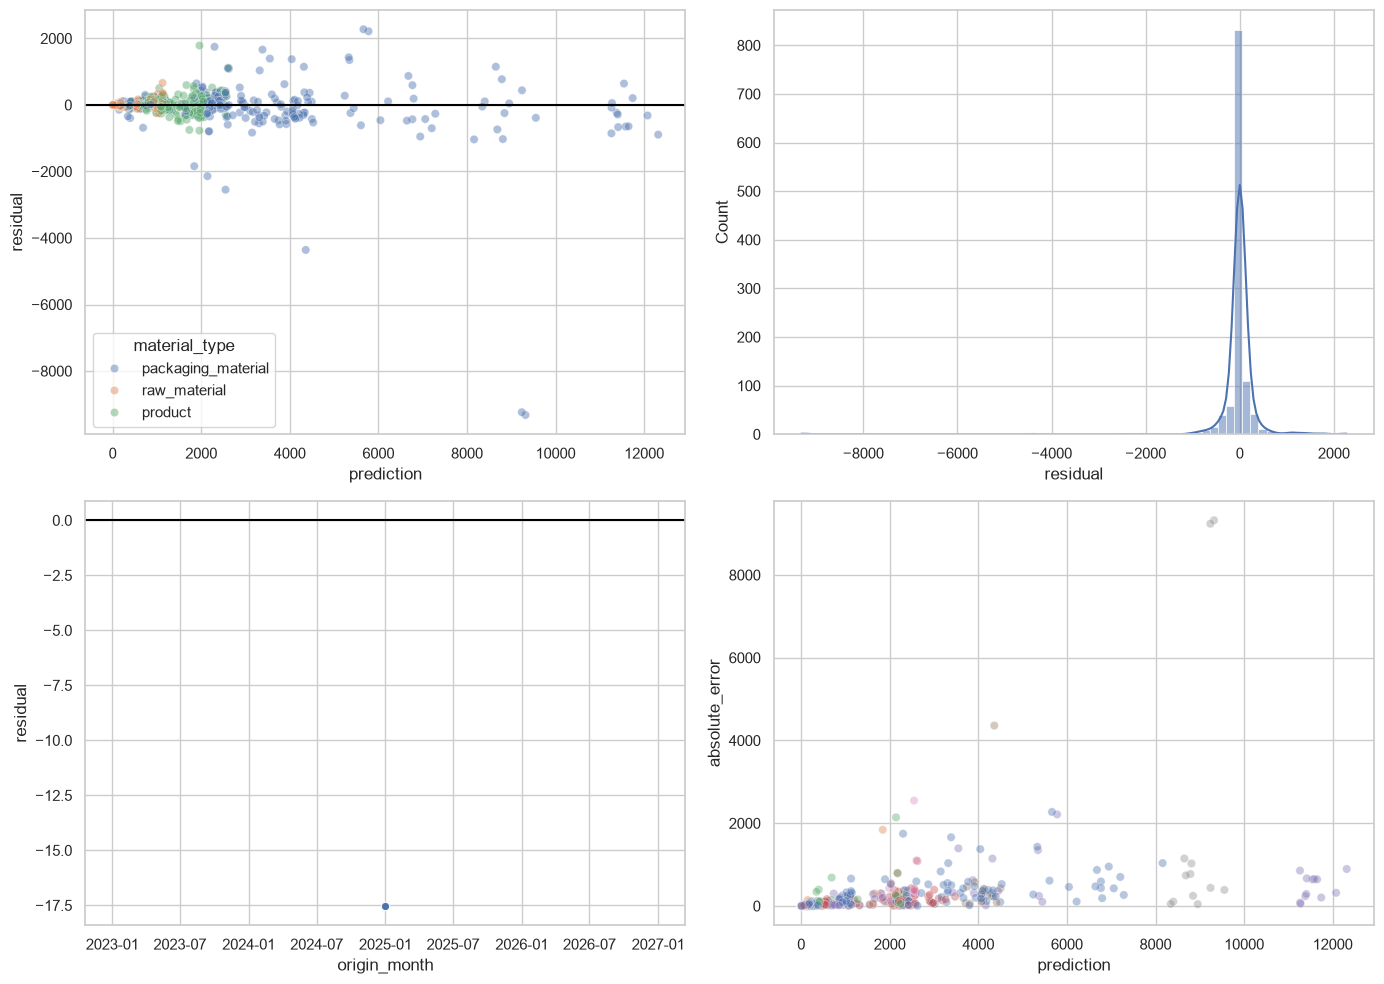

In [2]:
rows=pd.read_csv(OUT/'champion_test_backtest_rows.csv.gz',parse_dates=['origin_month'])
fig,axes=plt.subplots(2,2,figsize=(14,10))
sns.scatterplot(data=rows,x='prediction',y='residual',hue='material_type',alpha=.45,ax=axes[0,0]); axes[0,0].axhline(0,color='black')
sns.histplot(rows.residual,kde=True,ax=axes[0,1])
sns.lineplot(data=rows.groupby('origin_month').residual.mean().reset_index(),x='origin_month',y='residual',marker='o',ax=axes[1,0]); axes[1,0].axhline(0,color='black')
sns.scatterplot(data=rows,x='prediction',y='absolute_error',hue='amalgamated_class',alpha=.4,legend=False,ax=axes[1,1]); plt.tight_layout(); plt.show()

In [3]:
coverage=rows.groupby(['material_type','amalgamated_class']).interval_covered.agg(['mean','size']).reset_index()
display(coverage.sort_values('mean'))
print('Aggregate empirical coverage:',rows.interval_covered.mean())

,material_type,amalgamated_class,mean,size
1,packaging_material,AM,0.333333,12
2,packaging_material,AS,0.333333,12
4,packaging_material,BM,0.666667,12
0,packaging_material,AF,0.683333,120
5,packaging_material,CF,0.802083,96
3,packaging_material,BF,0.850000,60
7,packaging_material,CS,0.854167,48
6,packaging_material,CM,0.875000,24
8,raw_material,AF,0.985294,204
9,raw_material,BF,1.000000,132


Aggregate empirical coverage: 0.8914930555555556


In [4]:
from scipy import stats
print('Jarque-Bera:',stats.jarque_bera(rows.residual))
print('Spearman |residual| vs fitted:',stats.spearmanr(rows.absolute_error,rows.prediction))

Jarque-Bera: SignificanceResult(statistic=np.float64(2586532.72957152), pvalue=np.float64(0.0))
Spearman |residual| vs fitted: SignificanceResult(statistic=np.float64(0.8630313861596777), pvalue=np.float64(0.0))


In [5]:
assumptions=pd.read_csv(EVAL/'assumption_registry.csv')
residual_tests=pd.read_csv(EVAL/'residual_diagnostics.csv')
calibration=pd.read_csv(EVAL/'interval_calibration.csv')
display(assumptions)
display(residual_tests)
display(calibration)

,assumption,status,evidence,action
0,Temporal ordering and no random K-fold,SUPPORTED,Expanding-origin H1-H12 protocol with a locked...,Keep all preprocessing inside each origin.
1,Annual seasonality is present,SUPPORTED,33.3% of series pass AR(1)-red-noise annual sp...,Retain cyclic and spectral ablations; do not f...
2,Series are stationary,NOT_REQUIRED,69.8% pass joint ADF/KPSS evidence.,Trees and neural models do not require station...
3,Residuals are centered,REJECTED,HAC intercept test on monthly aggregate residu...,Keep bias in the selection score and monitor b...
4,Residuals are serially uncorrelated,SUPPORTED,Ljung-Box test on monthly aggregate residuals.,Use HAC/block inference regardless of outcome.
5,Residuals are Gaussian,NOT_REQUIRED,Jarque-Bera is reported but Gaussian intervals...,Use empirical/quantile intervals and block-boo...
6,Residual variance is constant,REJECTED,Breusch-Pagan and scale-error tests.,Use scale-normalized intervals and slice metrics.
7,P10-P90 intervals are calibrated,SUPPORTED,Untouched-test block-bootstrap coverage interval.,Recalibrate on pre-test residuals if rejected.
8,Generated sample represents the operational po...,UNVERIFIED,All current histories are controlled/generated...,"Require representative real issue history, pop..."


,test,statistic,p_value,null_hypothesis,status
0,HAC mean residual equals zero,-2.341073e+00,1.922839e-02,mean residual is zero,REJECTED
1,Ljung-Box monthly residual lag 4,8.745408e+00,6.778783e-02,no residual autocorrelation,SUPPORTED
2,Jarque-Bera normality,1.899561e+06,0.000000e+00,residuals are normally distributed,NOT_REQUIRED
3,Breusch-Pagan constant variance,4.715268e+01,6.566675e-12,residual variance is constant,REJECTED
4,Spearman absolute residual versus fitted,8.559345e-01,1.175528e-276,error scale is unrelated to fitted scale,REJECTED


,model_name,nominal_coverage,empirical_coverage,coverage_ci_low,coverage_ci_high,average_interval_width,calibration_source
0,CONV1D_ATTENTION_GLOBAL,0.8,0.772569,0.744792,0.800803,718.934897,pre-test rolling-origin residuals only
1,CROSTON_SBA,0.8,0.783854,0.746940,0.817708,773.624234,pre-test rolling-origin residuals only
2,ETS_A_N_A,0.8,0.801215,0.769510,0.829449,845.691361,pre-test rolling-origin residuals only
3,EXTRA_TREES,0.8,0.815104,0.784722,0.845074,595.734646,pre-test rolling-origin residuals only
4,EXTRA_TREES_DAMPED_TREND,0.8,0.802951,0.771246,0.833789,638.483350,pre-test rolling-origin residuals only
5,EXTRA_TREES_RESPONSIVE,0.8,0.812500,0.784266,0.836806,589.022390,pre-test rolling-origin residuals only
6,LIGHTGBM,0.8,0.801215,0.772114,0.824653,604.031175,pre-test rolling-origin residuals only
7,MOVING_AVERAGE_3,0.8,0.767361,0.722222,0.804275,941.318568,pre-test rolling-origin residuals only
8,SEASONAL_NAIVE,0.8,0.802083,0.774306,0.830317,994.218445,pre-test rolling-origin residuals only
